In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

from plots import plot_metrics

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch: 2.9.1+cu128
CUDA available: True
Using device: cuda


In [2]:
# Load raw and preprocessed data
d = np.load("data/dataset_splits.npz")
X_train_full = d["X_train"]
X_test_raw = d["X_test"]
y_train_full = d["y_train"].ravel()
y_test = d["y_test"].ravel()

pp = np.load("data/predictions/snv_sg1_preprocessed_spectra.npz")
X_train_pp_full = pp["X_train_pp"]
X_test_pp = pp["X_test_pp"]

print("Raw  — train:", X_train_full.shape, "test:", X_test_raw.shape)
print("Preprocessed — train:", X_train_pp_full.shape, "test:", X_test_pp.shape)

bins = np.quantile(y_train_full, np.linspace(0, 1, 20))
y_binned = np.digitize(y_train_full, bins[1:-1])

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_binned
)

X_train_pp, X_val_pp, _, _ = train_test_split(
    X_train_pp_full, y_train_full, test_size=0.2, random_state=42, stratify=y_binned
)

print(f"\nTrain: {X_train_raw.shape[0]}, Val: {X_val_raw.shape[0]}, Test: {X_test_raw.shape[0]}")

# StandardScale raw spectra
scaler_raw = StandardScaler()
X_train_s = scaler_raw.fit_transform(X_train_raw).astype(np.float32)
X_val_s = scaler_raw.transform(X_val_raw).astype(np.float32)
X_test_s = scaler_raw.transform(X_test_raw).astype(np.float32)

# StandardScale preprocessed spectra
scaler_pp = StandardScaler()
X_train_pp_s = scaler_pp.fit_transform(X_train_pp).astype(np.float32)
X_val_pp_s = scaler_pp.transform(X_val_pp).astype(np.float32)
X_test_pp_s = scaler_pp.transform(X_test_pp).astype(np.float32)

# Create DataLoaders
def make_loaders(X_tr, X_v, X_te, y_tr, y_v, batch_size=64):
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr.astype(np.float32)))
    val_ds = TensorDataset(torch.from_numpy(X_v), torch.from_numpy(y_v.astype(np.float32)))
    test_ds = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_test.astype(np.float32)))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    test_loader = DataLoader(test_ds, batch_size=batch_size)
    return train_loader, val_loader, test_loader

train_loader_raw, val_loader_raw, test_loader_raw = make_loaders(X_train_s, X_val_s, X_test_s, y_train, y_val)
train_loader_pp, val_loader_pp, test_loader_pp = make_loaders(X_train_pp_s, X_val_pp_s, X_test_pp_s, y_train, y_val)
print("DataLoaders ready.")

Raw  — train: (1254, 1000) test: (314, 1000)
Preprocessed — train: (1254, 1000) test: (314, 1000)

Train: 1003, Val: 251, Test: 314
DataLoaders ready.


In [3]:
class FCN(nn.Module):
    def __init__(self, input_dim=1000, layers=(512, 256, 128), dropout=0.2):
        super().__init__()
        modules = []
        in_features = input_dim
        for out_features in layers:
            modules.append(nn.Linear(in_features, out_features))
            modules.append(nn.BatchNorm1d(out_features))
            modules.append(nn.ReLU())
            modules.append(nn.Dropout(dropout))
            in_features = out_features
        # Remove last dropout
        modules.pop()
        modules.append(nn.Linear(in_features, 1))
        self.net = nn.Sequential(*modules)

    def forward(self, x):
        return self.net(x).squeeze(-1)

model = FCN().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

FCN(
  (net): Sequential(
    (0): Linear(in_features=1000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total parameters: 678,657


In [4]:
def compute_r2(model, loader):
    model.eval()
    all_y, all_pred = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            all_pred.append(model(X_batch).cpu().numpy())
            all_y.append(y_batch.numpy())
    return r2_score(np.concatenate(all_y), np.concatenate(all_pred))

def train_model(model, train_loader, val_loader, epochs=200, patience=20, lr=1e-3, weight_decay=1e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    history = {"train_loss": [], "val_loss": [], "train_r2": [], "val_r2": []}
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # Validate
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        train_r2 = compute_r2(model, train_loader)
        val_r2 = compute_r2(model, val_loader)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_r2"].append(train_r2)
        history["val_r2"].append(val_r2)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 20 == 0 or epoch == 1 or patience_counter == patience:
            print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train R²: {train_r2:.3f} | Val R²: {val_r2:.3f} | Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    model.to(device)
    return history

# Train on raw data
print("=" * 60)
print("Training FCN on RAW spectra")
print("=" * 60)
model_raw = FCN().to(device)
history_raw = train_model(model_raw, train_loader_raw, val_loader_raw)

Training FCN on RAW spectra
Epoch   1 | Train Loss: 441.0414 | Val Loss: 334.7542 | Train R²: -0.703 | Val R²: -0.740 | Patience: 0/20
Epoch  20 | Train Loss: 112.5106 | Val Loss: 104.0480 | Train R²: 0.441 | Val R²: 0.458 | Patience: 4/20
Epoch  40 | Train Loss: 109.7193 | Val Loss: 84.5425 | Train R²: 0.537 | Val R²: 0.560 | Patience: 1/20
Epoch  60 | Train Loss: 97.5592 | Val Loss: 80.9701 | Train R²: 0.567 | Val R²: 0.579 | Patience: 0/20
Epoch  80 | Train Loss: 102.8979 | Val Loss: 96.5753 | Train R²: 0.503 | Val R²: 0.497 | Patience: 12/20
Epoch  88 | Train Loss: 108.2234 | Val Loss: 93.4854 | Train R²: 0.472 | Val R²: 0.517 | Patience: 20/20
Early stopping at epoch 88


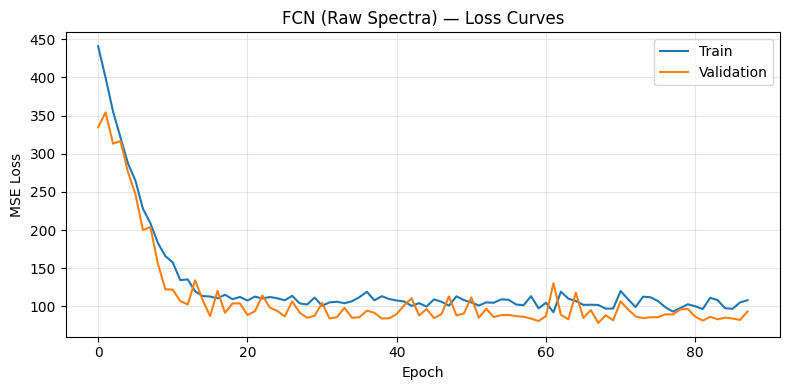

In [5]:
def plot_loss(history, title="Training"):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["train_loss"], label="Train")
    ax.plot(history["val_loss"], label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title(f"{title} — Loss Curves")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

plot_loss(history_raw, "FCN (Raw Spectra)")

FCN (Raw Spectra) — R²: 0.542, RMSE: 10.480, RPD: 1.48


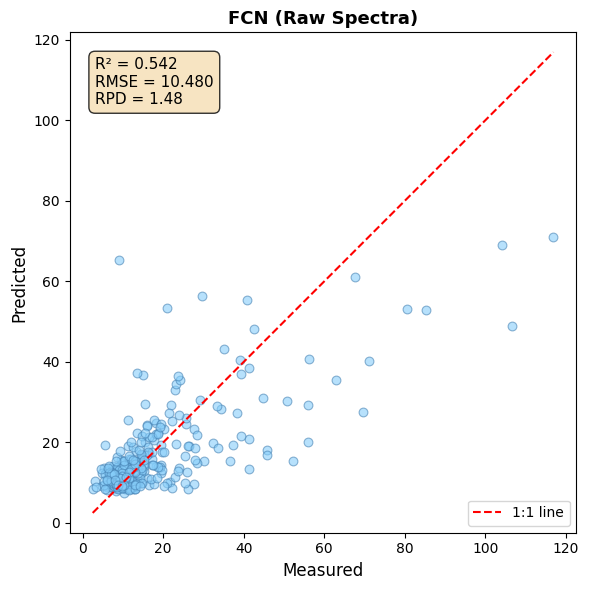

In [6]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    preds = []
    for X_batch, _ in loader:
        X_batch = X_batch.to(device)
        preds.append(model(X_batch).cpu().numpy())
    return np.concatenate(preds)

# Evaluate on test set (raw spectra)
y_pred_raw = predict(model_raw, test_loader_raw)

r2 = r2_score(y_test, y_pred_raw)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_raw))
rpd = np.std(y_test) / rmse
print(f"FCN (Raw Spectra) — R²: {r2:.3f}, RMSE: {rmse:.3f}, RPD: {rpd:.2f}")

plot_metrics(y_test, y_pred_raw, "FCN (Raw Spectra)")

In [7]:
# Train on preprocessed (SNV + SG1) data
print("=" * 60)
print("Training FCN on PREPROCESSED spectra (SNV + SG1)")
print("=" * 60)
model_pp = FCN().to(device)
history_pp = train_model(model_pp, train_loader_pp, val_loader_pp)

Training FCN on PREPROCESSED spectra (SNV + SG1)
Epoch   1 | Train Loss: 420.5718 | Val Loss: 272.0864 | Train R²: -0.301 | Val R²: -0.412 | Patience: 0/20
Epoch  20 | Train Loss: 50.9220 | Val Loss: 84.4639 | Train R²: 0.798 | Val R²: 0.560 | Patience: 2/20
Epoch  40 | Train Loss: 36.0906 | Val Loss: 56.4010 | Train R²: 0.881 | Val R²: 0.706 | Patience: 5/20
Epoch  55 | Train Loss: 32.9332 | Val Loss: 63.7256 | Train R²: 0.907 | Val R²: 0.668 | Patience: 20/20
Early stopping at epoch 55


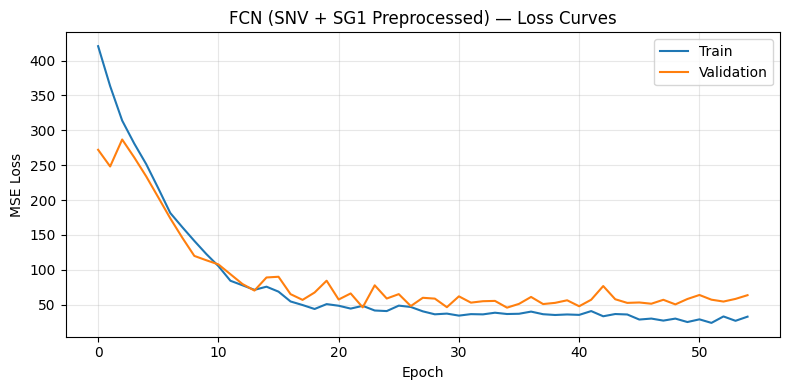

FCN (SNV+SG1) — R²: 0.820, RMSE: 6.568, RPD: 2.36


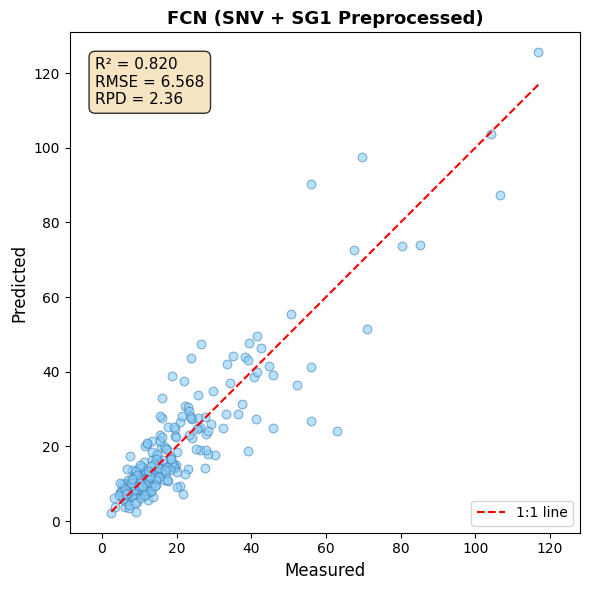

In [8]:
plot_loss(history_pp, "FCN (SNV + SG1 Preprocessed)")

# Evaluate on test set (preprocessed spectra)
y_pred_test_pp = predict(model_pp, test_loader_pp)

r2 = r2_score(y_test, y_pred_test_pp)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_pp))
rpd = np.std(y_test) / rmse
print(f"FCN (SNV+SG1) — R²: {r2:.3f}, RMSE: {rmse:.3f}, RPD: {rpd:.2f}")

plot_metrics(y_test, y_pred_test_pp, "FCN (SNV + SG1 Preprocessed)")

In [9]:
np.savez_compressed(
    "data/predictions/fcn_snv_sg1_preds.npz",
    pred_train=predict(model_pp, train_loader_pp),
    pred_test=y_pred_test_pp
)

In [10]:
# Re-save with full train predictions (1254 samples instead of 1003)
X_train_pp_full_s = scaler_pp.transform(X_train_pp_full).astype(np.float32)
full_train_ds = TensorDataset(
    torch.from_numpy(X_train_pp_full_s),
    torch.from_numpy(y_train_full.astype(np.float32)),
)
full_train_loader = DataLoader(full_train_ds, batch_size=64)

pred_train_full = predict(model_pp, full_train_loader)
print(f"Full train predictions shape: {pred_train_full.shape}")  # expect (1254,)
print(f"Test predictions shape:       {y_pred_test_pp.shape}")   # expect (314,)

np.savez_compressed(
    "data/predictions/fcn_snv_sg1_preds.npz",
    pred_train=pred_train_full,
    pred_test=y_pred_test_pp,
)

Full train predictions shape: (1254,)
Test predictions shape:       (314,)


In [17]:
import joblib
torch.save(model_pp.state_dict(), "data/predictions/fcn_model_pp.pt")
joblib.dump(scaler_pp, "data/predictions/fcn_scaler_pp.pkl")
print("Saved FCN model and scaler.")

Saved FCN model and scaler.


In [11]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [12]:
def optuna_objective(trial, train_loader, val_loader):
    # Architecture search space
    n_layers = trial.suggest_int("n_layers", 1, 5)
    layers = []
    in_dim = 1000
    for i in range(n_layers):
        out_dim = trial.suggest_int(f"layer_{i}_dim", 1, 60, log=True)
        layers.append(out_dim)
        in_dim = out_dim

    dropout = trial.suggest_float("dropout", 0.0, 0.5, step=0.05)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    model = FCN(input_dim=1000, layers=tuple(layers), dropout=dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    patience_counter = 0
    patience = 15

    for epoch in range(1, 151):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                val_losses.append(criterion(model(X_batch), y_batch).item())
        val_loss = np.mean(val_losses)

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_val_loss

N_TRIALS = 50

# --- Tune on RAW spectra ---
print("=" * 60)
print(f"Optuna: tuning FCN on RAW spectra ({N_TRIALS} trials)")
print("=" * 60)
study_raw = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study_raw.optimize(
    lambda trial: optuna_objective(trial, train_loader_raw, val_loader_raw),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

print(f"\nBest val loss: {study_raw.best_value:.4f}")
print("Best params:")
for k, v in study_raw.best_params.items():
    print(f"  {k}: {v}")

Optuna: tuning FCN on RAW spectra (50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]


Best val loss: 63.0907
Best params:
  n_layers: 2
  layer_0_dim: 6
  layer_1_dim: 10
  dropout: 0.0
  lr: 0.0052903009392984085
  weight_decay: 0.006499035943277226


Best architecture (raw): layers=(6, 10), dropout=0.0, lr=5.29e-03, wd=6.50e-03
Epoch   1 | Train Loss: 475.1081 | Val Loss: 446.8807 | Train R²: -1.266 | Val R²: -1.323 | Patience: 0/20
Epoch  20 | Train Loss: 97.2524 | Val Loss: 81.1608 | Train R²: 0.551 | Val R²: 0.579 | Patience: 0/20
Epoch  40 | Train Loss: 83.3692 | Val Loss: 69.6815 | Train R²: 0.604 | Val R²: 0.638 | Patience: 0/20
Epoch  60 | Train Loss: 76.1254 | Val Loss: 82.0771 | Train R²: 0.519 | Val R²: 0.575 | Patience: 1/20
Epoch  80 | Train Loss: 86.6113 | Val Loss: 69.9426 | Train R²: 0.633 | Val R²: 0.636 | Patience: 6/20
Epoch  94 | Train Loss: 79.5187 | Val Loss: 158.1970 | Train R²: 0.060 | Val R²: 0.180 | Patience: 20/20
Early stopping at epoch 94


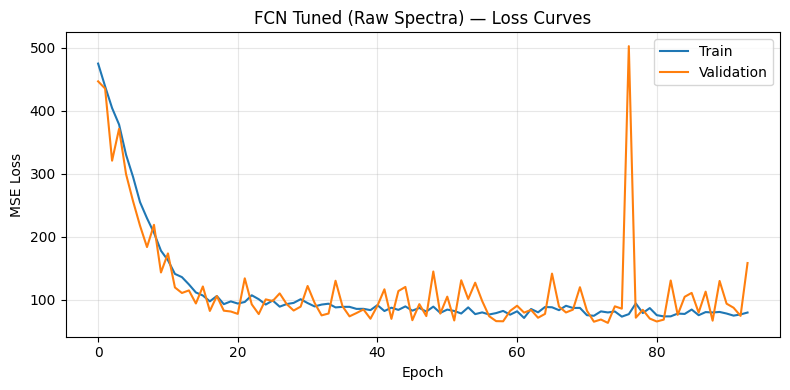

FCN Tuned (Raw) — R²: 0.680, RMSE: 8.757, RPD: 1.77


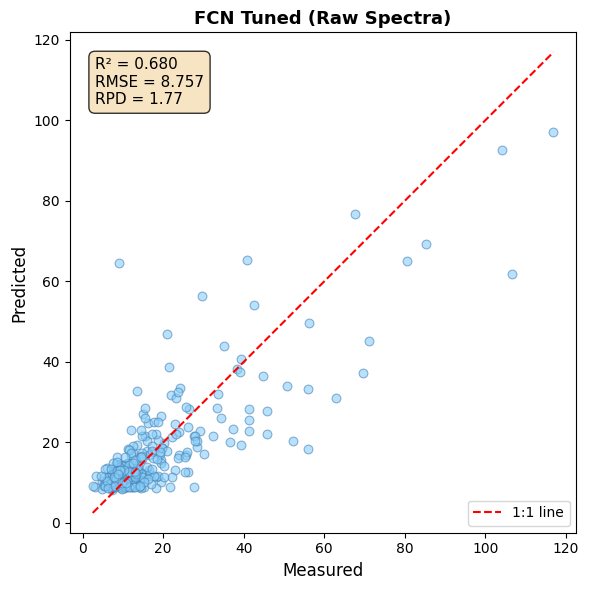

In [13]:
# Retrain best architecture on RAW spectra (full training with logging)
bp = study_raw.best_params
best_layers_raw = tuple(bp[f"layer_{i}_dim"] for i in range(bp["n_layers"]))
print(f"Best architecture (raw): layers={best_layers_raw}, dropout={bp['dropout']}, lr={bp['lr']:.2e}, wd={bp['weight_decay']:.2e}")

model_raw_tuned = FCN(layers=best_layers_raw, dropout=bp["dropout"]).to(device)
history_raw_tuned = train_model(
    model_raw_tuned, train_loader_raw, val_loader_raw,
    lr=bp["lr"], weight_decay=bp["weight_decay"],
)

plot_loss(history_raw_tuned, "FCN Tuned (Raw Spectra)")

y_pred_raw_tuned = predict(model_raw_tuned, test_loader_raw)
r2 = r2_score(y_test, y_pred_raw_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_raw_tuned))
rpd = np.std(y_test) / rmse
print(f"FCN Tuned (Raw) — R²: {r2:.3f}, RMSE: {rmse:.3f}, RPD: {rpd:.2f}")
plot_metrics(y_test, y_pred_raw_tuned, "FCN Tuned (Raw Spectra)")

In [14]:
# --- Tune on PREPROCESSED spectra ---
print("=" * 60)
print(f"Optuna: tuning FCN on PREPROCESSED spectra ({N_TRIALS} trials)")
print("=" * 60)
study_pp = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study_pp.optimize(
    lambda trial: optuna_objective(trial, train_loader_pp, val_loader_pp),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

print(f"\nBest val loss: {study_pp.best_value:.4f}")
print("Best params:")
for k, v in study_pp.best_params.items():
    print(f"  {k}: {v}")

Optuna: tuning FCN on PREPROCESSED spectra (50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]


Best val loss: 43.4647
Best params:
  n_layers: 2
  layer_0_dim: 15
  layer_1_dim: 10
  dropout: 0.1
  lr: 0.0054404058496452445
  weight_decay: 0.005275687990607234


Best architecture (pp): layers=(15, 10), dropout=0.1, lr=5.44e-03, wd=5.28e-03
Epoch   1 | Train Loss: 474.1155 | Val Loss: 425.3038 | Train R²: -1.130 | Val R²: -1.210 | Patience: 0/20
Epoch  20 | Train Loss: 59.7119 | Val Loss: 49.3255 | Train R²: 0.795 | Val R²: 0.744 | Patience: 2/20
Epoch  40 | Train Loss: 40.8788 | Val Loss: 49.5554 | Train R²: 0.847 | Val R²: 0.741 | Patience: 18/20
Epoch  42 | Train Loss: 41.7391 | Val Loss: 54.6223 | Train R²: 0.849 | Val R²: 0.715 | Patience: 20/20
Early stopping at epoch 42


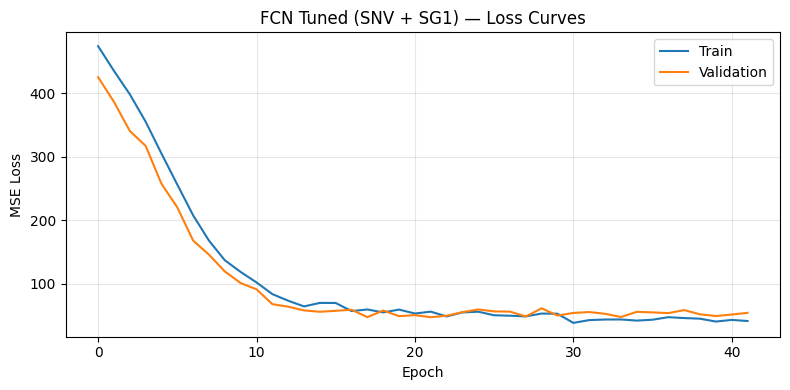

FCN Tuned (SNV+SG1) — R²: 0.794, RMSE: 7.028, RPD: 2.20


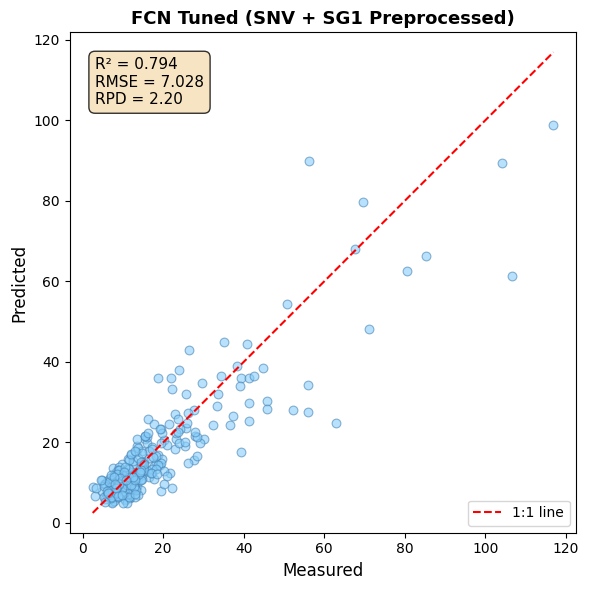

In [16]:
# Retrain best architecture on PREPROCESSED spectra
bp_pp = study_pp.best_params
best_layers_pp = tuple(bp_pp[f"layer_{i}_dim"] for i in range(bp_pp["n_layers"]))
print(f"Best architecture (pp): layers={best_layers_pp}, dropout={bp_pp['dropout']}, lr={bp_pp['lr']:.2e}, wd={bp_pp['weight_decay']:.2e}")

model_pp_tuned = FCN(layers=best_layers_pp, dropout=bp_pp["dropout"]).to(device)
history_pp_tuned = train_model(
    model_pp_tuned, train_loader_pp, val_loader_pp,
    lr=bp_pp["lr"], weight_decay=bp_pp["weight_decay"],
)

plot_loss(history_pp_tuned, "FCN Tuned (SNV + SG1)")

y_pred_pp_tuned = predict(model_pp_tuned, test_loader_pp)
r2 = r2_score(y_test, y_pred_pp_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_pp_tuned))
rpd = np.std(y_test) / rmse
print(f"FCN Tuned (SNV+SG1) — R²: {r2:.3f}, RMSE: {rmse:.3f}, RPD: {rpd:.2f}")
plot_metrics(y_test, y_pred_pp_tuned, "FCN Tuned (SNV + SG1 Preprocessed)")